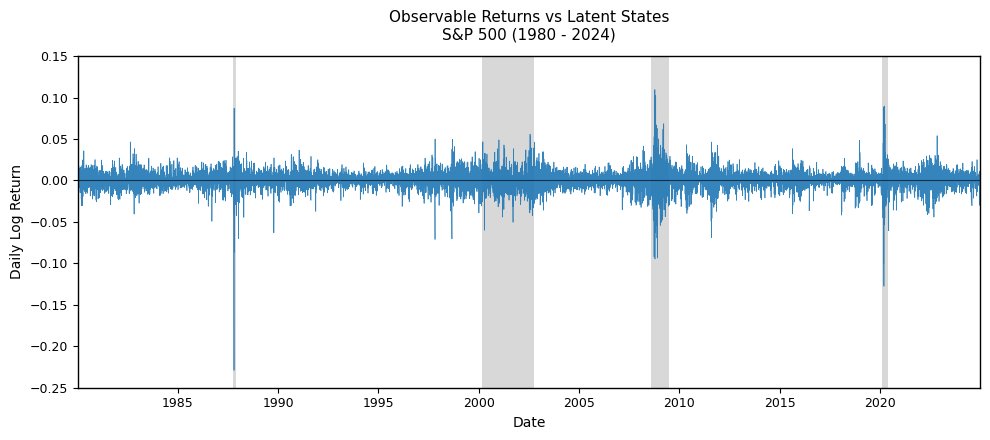

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Figure 2.3 — Observable returns and latent states
# This notebook illustrates the distinction between observable market returns
# and shaded latent volatility periods used as a conceptual visual reference

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style settings
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Data download and cleaning
df = yf.download(
    "^GSPC",
    start="1980-01-01",
    end="2024-12-31",
    interval="1d",
    progress=False
)

# Handle possible multi-level columns returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Remove missing observations and compute daily logarithmic returns
df = df.dropna()
df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna()

# Figure construction
fig, ax = plt.subplots(figsize=(10, 4.5))

# Plot the observable variable: daily log-returns
ax.plot(
    df.index,
    df["Log_Returns"],
    linewidth=0.5,
    color="#1f77b4",
    alpha=0.9
)

ax.axhline(y=0, color="black", linewidth=0.8, alpha=0.6)

# Define selected latent stress periods to shade in the plot
latent_states = [
    ("1987-10-01", "1987-11-30"),
    ("2000-03-01", "2002-10-01"),
    ("2008-08-01", "2009-06-30"),
    ("2020-02-15", "2020-05-31")
]

# Add shaded regions representing latent market stress periods
for start, end in latent_states:
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color="grey",
        alpha=0.3,
        lw=0
    )

# Axis formatting and title
ax.set_title(
    "Observable Returns vs Latent States\nS&P 500 (1980 - 2024)",
    pad=12
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Log Return")
ax.set_xlim(df.index.min(), df.index.max())
ax.set_ylim(-0.25, 0.15)

for spine in ax.spines.values():
    spine.set_linewidth(1)

ax.grid(False)

# Export figure for the thesis
plt.tight_layout()
output_path = OUTPUT_DIR / "fig_2_3_partial_information.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()